# TCN for Sales Drop Detection

## Overview

This notebook is part of a multi-model comparison study (TCN, LightGBM, Isolation Forest)
for detecting anomalous hourly sales drops caused by out-of-stock events.
All models share the same data, preprocessing pipeline, and anomaly scoring logic
to ensure a fair comparison.

A Temporal Convolutional Network is trained to forecast hourly sales one step ahead.
Anomalies are identified as hours where the model predicted significant sales
but actual sales were zero or near zero — producing a large positive residual.
The z-score of this residual is used as the anomaly score.

**Active threshold: z > 2.0**

## Setup

- **Data**: hourly sales, January–August 2025
- **Scope**: top-500 products by August volume + 13 products with known labeled anomalies
- **Model**: global TCN with product/category embeddings, 168-hour lookback window
- **Training**: AdamW optimizer, Huber loss (delta=1.0), early stopping (patience=3)
- **Loss function**: intentionally aligned with LightGBM (`objective='huber'`) to
  eliminate loss function differences from the comparison
- **Anomaly scoring**: residual z-score with mandatory pre-filters
  (stock > 0 at t and t-1, operating hours 07:00–22:00)

## Results on labeled anomalies

The model detected **26 out of 65** labeled anomalies at threshold z > 2.0
(recall 40.0%, precision 7.9%, 10.7 alerts/day).

The 39 missed anomalies occur predominantly in low-activity hours (07:00–08:00, 22:00)
where the model's baseline prediction is already near zero — the drop is
statistically indistinguishable from a normally quiet period.

## Data pipeline correction

An earlier version of this notebook used `data_v1.csv` for both training and test,
meaning the 65 synthetic anomaly hours (zeroed sales) were absent from the test set.
This has been corrected: August is now replaced with `df_aug_final.csv` which contains
the injected zeros. Training uses only January–July data and is unaffected.

## Validation split note

Due to TCN's 168-hour sliding window requirement, the validation dataframe includes
July 18–31 to ensure sufficient samples for loss computation. The actual validation
boundary matches LightGBM exactly — July 25–31 — since samples with targets before
July 25 are excluded by the window construction. July 18–24 serves only as lookback
context, analogous to the July 29–31 context used in the test set.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, mean_absolute_error
import gc
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm

In [2]:
DATA_PATH     = 'data_v1.csv'
AUG_AN_PATH   = 'df_aug_final.csv'
AUG_ZERO_PATH = 'df_aug_final_check_rows.csv'
MODEL_PATH    = 'best_tcn_hourly.pt'
ANOMALIES_OUTPUT_PATH = 'detected_anomalies_august.csv'

In [3]:
df = pd.read_csv(DATA_PATH)
df['date'] = pd.to_datetime(df['date'])
print("Initial size:", df.shape)

# Replace August with anomaly-injected version (zeros at known anomaly hours)
df_aug_final = pd.read_csv(AUG_AN_PATH)
df_aug_final['date'] = pd.to_datetime(df_aug_final['date'])
df = df[df['date'] < '2025-08-01'].copy()
df = pd.concat([df, df_aug_final], ignore_index=True)
del df_aug_final
gc.collect()

print(f"After replacing August: {df.shape}, period: {df['date'].min()} — {df['date'].max()}")

# Keep data up to August 31
df = df[df['date'] <= '2025-08-31'].copy()

Initial size: (64081080, 6)
After replacing August: (43218240, 7), period: 2025-01-15 00:00:00 — 2025-08-31 23:00:00


## Model Architecture

The model is a **global Temporal Convolutional Network** — a single model trained across all products simultaneously, rather than one model per SKU. This design is deliberate: with 500+ products and sparse hourly sales, per-product models would either underfit (insufficient data) or fail to generalise across products with similar demand patterns. A global model learns shared temporal structure while using product and category embeddings to capture SKU-specific behaviour.

**Input representation** — each training sample consists of a 168-hour lookback window (one full week) of five time-varying channels: log-transformed sales, price, hour of day, day of week, and weekend flag. Product identity and category are encoded as learned embeddings (dimension 64 and 32 respectively) and concatenated to the time-varying features at each time step. This allows the model to condition its forecast on stable SKU characteristics without requiring separate model instances.

**TCN blocks** — six dilated causal convolutional blocks with dilation factors [1, 2, 4, 8, 16, 32]. The exponentially increasing dilation gives the network a theoretical receptive field of 2 × (2^6 − 1) × (kernel\_size − 1) + 1 = 126 time steps at the deepest layer, covering the full 168-hour window without recurrence. Each block applies two Conv1d layers (kernel size 3), ReLU activations, dropout (p = 0.2), and a residual connection to stabilise gradient flow through depth.

**Output head** — a two-layer MLP (128 → 64 → 1) maps the final hidden state to a scalar sales forecast. The model predicts log1p-transformed sales; residuals for anomaly scoring are computed in the original sales scale.

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

print("Initial size:", df.shape)
print(df.head(3))

df = df[df['date'] <= '2025-08-31'].copy()

first_pos = df[df['sales'] > 0].groupby('product')['date'].min()
aug_start = pd.Timestamp('2025-08-01')
cold = first_pos[first_pos >= aug_start].index.tolist()
df = df[~df['product'].isin(cold)].copy()
print(f"After removing cold products: {df.shape}")

aug_df = df[df['date'] >= aug_start].copy()
prod_sales = aug_df.groupby('product')['sales'].sum().reset_index()
prod_sales.columns = ['product', 'total_sales']

top_500 = prod_sales.nlargest(500, 'total_sales')['product'].tolist()

df_aug_zero = pd.read_csv(AUG_ZERO_PATH)
anomaly_products = df_aug_zero['product'].unique().tolist()
print(f"Products with known anomalies: {len(anomaly_products)}")

selected_products = list(set(top_500 + anomaly_products))
print(f"Top-500 (August only): {len(top_500)} | Anomaly products: {len(anomaly_products)} | Total: {len(selected_products)}")

df = df[df['product'].isin(selected_products)].copy()
print(f"After filtering: {df.shape}")

del first_pos, cold, prod_sales, top_500, df_aug_zero, anomaly_products, selected_products, aug_df
gc.collect()

Device: cuda
Initial size: (43058022, 7)
        date          product   category  stocks  sales  price  hour
0 2025-01-15  178462000592214  161040302     5.0    0.0  799.8   NaN
1 2025-01-15  178462000291408  162110101     1.0    0.0  199.9   NaN
2 2025-01-15  178462000544616  161011010     2.0    0.0  119.9   NaN
After removing cold products: (43058022, 7)
Products with known anomalies: 13
Top-500 (August only): 500 | Anomaly products: 13 | Total: 500
After filtering: (2736500, 7)


0

In [5]:
df = df.sort_values(['product', 'date']).reset_index(drop=True)
df['hour'] = df['date'].dt.hour
df['dayofweek'] = df['date'].dt.dayofweek
df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)
df['sales_log'] = np.log1p(df['sales'])
df['stocks_lag_1h'] = df.groupby('product')['stocks'].shift(1)

product_encoder = LabelEncoder()
category_encoder = LabelEncoder()
df['product_id'] = product_encoder.fit_transform(df['product'])
df['category_id'] = category_encoder.fit_transform(df['category'])

num_products   = df['product_id'].nunique()
num_categories = df['category_id'].nunique()
print(f"Products: {num_products}, Categories: {num_categories}")


class HourlyTCNDataset(Dataset):
    def __init__(self, df, window=168, target_horizon=1):
        self.window = window
        self.target_horizon = target_horizon
        self.samples = []
        self.product_data = {}

        for prod_id in tqdm(df['product_id'].unique(), desc="Preloading products"):
            prod_df = df[df['product_id'] == prod_id].reset_index(drop=True)
            if len(prod_df) < window + target_horizon:
                continue
            self.product_data[prod_id] = {
                'sales':      torch.tensor(prod_df['sales_log'].values, dtype=torch.float32),
                'price':      torch.tensor(prod_df['price'].values,     dtype=torch.float32),
                'hour':       torch.tensor(prod_df['hour'].values,      dtype=torch.float32),
                'dow':        torch.tensor(prod_df['dayofweek'].values, dtype=torch.float32),
                'is_weekend': torch.tensor(prod_df['is_weekend'].values,dtype=torch.float32),
                'category_id':torch.tensor(prod_df['category_id'].iloc[0], dtype=torch.long),
            }
            max_start = len(prod_df) - window - target_horizon + 1
            for i in range(max_start):
                self.samples.append((prod_id, i))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        prod_id, start = self.samples[idx]
        d   = self.product_data[prod_id]
        end = start + self.window
        return {
            'sales':       d['sales'][start:end],
            'price':       d['price'][start:end],
            'hour':        d['hour'][start:end],
            'dow':         d['dow'][start:end],
            'is_weekend':  d['is_weekend'][start:end],
            'product_id':  torch.tensor(prod_id, dtype=torch.long),
            'category_id': d['category_id'],
            'target':      d['sales'][end + self.target_horizon - 1]
        }

train_df = df[df['date'] <= '2025-07-24'].copy()
val_df   = df[(df['date'] >= '2025-07-18') & (df['date'] <= '2025-07-31')].copy()

train_dataset = HourlyTCNDataset(train_df, window=168, target_horizon=1)
val_dataset   = HourlyTCNDataset(val_df,   window=168, target_horizon=1)
print(f"Train samples: {len(train_dataset)}")
print(f"Val samples:   {len(val_dataset)}")

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=128, shuffle=False, num_workers=0, pin_memory=True)

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


Products: 500, Categories: 154


Preloading products: 100%|██████████| 500/500 [00:00<00:00, 988.09it/s]

Train samples: 2208500
Val samples:   72000


In [6]:
class TCNBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, dilation=1, dropout=0.2):
        super().__init__()
        self.padding = (kernel_size - 1) * dilation
        self.conv1   = nn.Conv1d(in_ch,  out_ch, kernel_size, padding=self.padding, dilation=dilation)
        self.conv2   = nn.Conv1d(out_ch, out_ch, kernel_size, padding=self.padding, dilation=dilation)
        self.relu    = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.res     = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x):
        out = self.relu(self.conv1(x))
        out = self.dropout(out)
        out = self.relu(self.conv2(out))
        out = self.dropout(out)
        out = out[:, :, :x.size(2)]
        return out + self.res(x)


class GlobalTCN(nn.Module):
    def __init__(self, num_products, num_categories, emb_dim=64, hidden=128, levels=6):
        super().__init__()
        self.product_emb  = nn.Embedding(num_products,   emb_dim)
        self.category_emb = nn.Embedding(num_categories, emb_dim // 2)
        input_dim = 5 + emb_dim + emb_dim // 2
        self.input_proj = nn.Linear(input_dim, hidden)
        dilations = [2 ** i for i in range(levels)]
        self.blocks = nn.ModuleList([TCNBlock(hidden, hidden, 3, d, 0.2) for d in dilations])
        self.head = nn.Sequential(nn.Linear(hidden, 64), nn.ReLU(), nn.Linear(64, 1))

    def forward(self, sales, price, hour, dow, is_weekend, product_id, category_id):
        p_emb = self.product_emb(product_id)
        c_emb = self.category_emb(category_id)
        x = torch.stack([sales, price, hour, dow, is_weekend], dim=-1)
        x = torch.cat([x,
                       p_emb.unsqueeze(1).expand(-1, x.size(1), -1),
                       c_emb.unsqueeze(1).expand(-1, x.size(1), -1)], dim=-1)
        x = self.input_proj(x).permute(0, 2, 1)
        for block in self.blocks:
            x = block(x)
        x = x[:, :, -1]
        return self.head(x).squeeze(-1)


model = GlobalTCN(num_products, num_categories).to(device)

In [7]:
from tqdm.auto import tqdm

optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
criterion = nn.HuberLoss(delta=1.0)

epochs           = 25
best_loss        = float('inf')
patience         = 3
patience_counter = 0
train_losses, val_losses = [], []


def run_epoch(loader, train=True):
    if train:
        model.train()
    else:
        model.eval()

    total_loss = 0
    ctx = torch.enable_grad() if train else torch.no_grad()

    desc   = "Training" if train else "Validation"
    loader = tqdm(loader, desc=desc, leave=False)

    with ctx:
        for batch in loader:
            sales       = batch['sales'].to(device,       non_blocking=True)
            price       = batch['price'].to(device,       non_blocking=True)
            hour        = batch['hour'].to(device,        non_blocking=True)
            dow         = batch['dow'].to(device,         non_blocking=True)
            is_weekend  = batch['is_weekend'].to(device,  non_blocking=True)
            product_id  = batch['product_id'].to(device,  non_blocking=True)
            category_id = batch['category_id'].to(device, non_blocking=True)
            target      = batch['target'].to(device,      non_blocking=True)

            if train:
                optimizer.zero_grad()

            pred = model(sales, price, hour, dow, is_weekend, product_id, category_id)
            loss = criterion(pred, target)

            if train:
                loss.backward()
                optimizer.step()

            total_loss += loss.item()
            loader.set_postfix(loss=f"{total_loss / (loader.n or 1):.4f}")

    return total_loss / len(loader)

## Training Configuration Justification

**`HuberLoss(delta = 1.0)`** — the log1p transformation compresses the sales scale, but occasional multi-unit spikes still produce large residuals. Huber loss reduces the gradient contribution of these spikes relative to MSE, preventing the model from over-optimising for rare high-sales hours at the expense of typical low-sales periods. `delta = 1.0` is the standard default and is appropriate for log-scale targets where the majority of residuals fall well below 1.0.

**`window = 168 hours`** — one full calendar week. The EDA confirms strong intraday seasonality (two daily peaks at 11–13 h and 17–18 h) and moderate intraweek variation. A 168-hour window ensures the model always conditions on at least one complete weekly cycle, which is the minimum context needed to distinguish a genuinely anomalous drop from a low-activity period that is normal for that hour and day combination.

**`AdamW`, `lr = 0.001`, `weight_decay = 1e-4`** — AdamW decouples weight decay from the gradient update, which consistently outperforms standard Adam on models with embeddings (Loshchilov & Hutter, 2019). The learning rate of 0.001 is the standard AdamW default for medium-sized networks; weight decay of 1e-4 provides light regularisation on the embedding parameters.

**`batch_size = 256` (train), `128` (validation)** — sufficiently large to stabilise gradient estimates across the heterogeneous product mix; memory-feasible on a single GPU for the 500-product scope.

**Early stopping, `patience = 3`** — training terminates when validation loss does not improve for 3 consecutive epochs; the best checkpoint is saved. With `max_epochs = 25` and the dataset size, early stopping typically triggers between epochs 8 and 15, preventing overfitting to the training period while avoiding unnecessary compute.

**Computational scope note** — the TCN is trained on the top-500 products by August volume. Scaling to the full product catalogue (~10,000 SKUs) would require either distributed training or significant architecture changes (e.g., per-category models), which falls outside the scope of this comparative study. LightGBM and Isolation Forest do not share this constraint, which constitutes a structural difference in scalability between the approaches.

Epochs:   0%|          | 0/25 [00:00<?, ?it/s]

Training:   0%|          | 0/8627 [00:00<?, ?it/s]

Validation:   0%|          | 0/563 [00:00<?, ?it/s]

Epoch 1/25 | Train Loss: 0.0642 | Val Loss: 0.0817
  -> Saved best model


Training:   0%|          | 0/8627 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/563 [00:00<?, ?it/s]

Epoch 10/25 | Train Loss: 0.0584 | Val Loss: 0.0789
  -> No improvement (2/3)


Training:   0%|          | 0/8627 [00:00<?, ?it/s]

Validation:   0%|          | 0/563 [00:00<?, ?it/s]

Epoch 11/25 | Train Loss: 0.0584 | Val Loss: 0.0795
  -> No improvement (3/3)

Early stopping at epoch 11


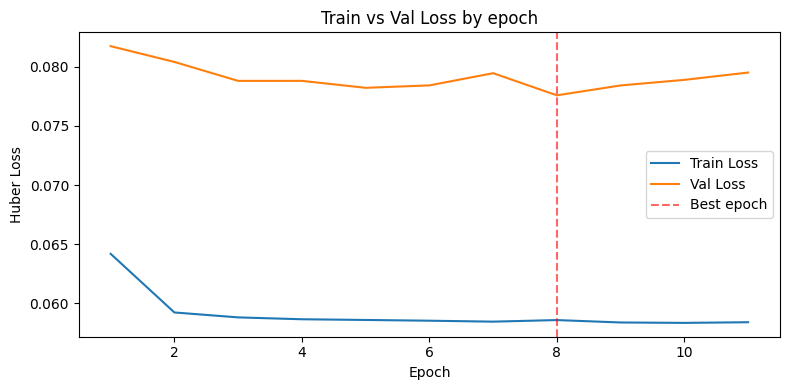


Training complete. Best Val Loss: 0.0776 (epoch 8)


In [8]:
epoch_bar = tqdm(range(epochs), desc="Epochs")

for epoch in epoch_bar:
    tr_loss  = run_epoch(train_loader, train=True)
    val_loss = run_epoch(val_loader,   train=False)

    train_losses.append(tr_loss)
    val_losses.append(val_loss)

    epoch_bar.set_postfix(train=f"{tr_loss:.4f}", val=f"{val_loss:.4f}")
    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {tr_loss:.4f} | Val Loss: {val_loss:.4f}")

    if val_loss < best_loss:
        best_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), MODEL_PATH)
        print("  -> Saved best model")
    else:
        patience_counter += 1
        print(f"  -> No improvement ({patience_counter}/{patience})")
        if patience_counter >= patience:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

# Train vs val loss plot
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(train_losses)+1), train_losses, label='Train Loss')
plt.plot(range(1, len(val_losses)+1),   val_losses,   label='Val Loss')
plt.axvline(x=val_losses.index(min(val_losses))+1,
            color='red', linestyle='--', alpha=0.6, label='Best epoch')
plt.xlabel('Epoch')
plt.ylabel('Huber Loss')
plt.title('Train vs Val Loss by epoch')
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nTraining complete. Best Val Loss: {best_loss:.4f} "
      f"(epoch {val_losses.index(min(val_losses))+1})")

In [9]:
model.load_state_dict(torch.load(MODEL_PATH, weights_only=True))
model.eval()

val_preds_log, val_targets_log = [], []

with torch.no_grad():
    for batch in tqdm(val_loader, desc="Predicting on val"):
        pred = model(
            batch['sales'].to(device),
            batch['price'].to(device),
            batch['hour'].to(device),
            batch['dow'].to(device),
            batch['is_weekend'].to(device),
            batch['product_id'].to(device),
            batch['category_id'].to(device)
        )
        val_preds_log.append(pred.cpu())
        val_targets_log.append(batch['target'].cpu())

val_preds_real   = np.expm1(torch.cat(val_preds_log).numpy())
val_targets_real = np.expm1(torch.cat(val_targets_log).numpy())

model_mae  = mean_absolute_error(val_targets_real, val_preds_real)
model_rmse = np.sqrt(mean_squared_error(val_targets_real, val_preds_real))

naive_mae  = mean_absolute_error(val_targets_real[1:], val_targets_real[:-1])
naive_rmse = np.sqrt(mean_squared_error(val_targets_real[1:], val_targets_real[:-1]))

print(f"{'Metric':<20} {'Baseline':>10} {'TCN':>10}")
print("=" * 42)
print(f"{'MAE':<20} {naive_mae:>10.3f} {model_mae:>10.3f}")
print(f"{'RMSE':<20} {naive_rmse:>10.3f} {model_rmse:>10.3f}")
print("=" * 42)
print(f"MAE improvement:  {(1 - model_mae/naive_mae)*100:.1f}%")
print(f"RMSE improvement: {(1 - model_rmse/naive_rmse)*100:.1f}%")

Predicting on val:   0%|          | 0/563 [00:00<?, ?it/s]

Metric                 Baseline        TCN
MAE                       0.682      0.513
RMSE                      2.046      1.551
MAE improvement:  24.9%
RMSE improvement: 24.2%


In [10]:
print("ANOMALY DETECTION (AUGUST)")

jul_context = df[(df['date'] >= '2025-07-29') & (df['date'] <= '2025-07-31')].copy()
aug_df = df[df['date'] >= '2025-08-01'].copy()
test_df = pd.concat([jul_context, aug_df]).sort_values(['product', 'date']).reset_index(drop=True)

print(f"Records (with context): {len(test_df)}")

test_dataset = HourlyTCNDataset(test_df, window=168, target_horizon=1)
test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False, num_workers=2, pin_memory=True)

all_preds, all_targets = [], []
with torch.no_grad():
    for batch in tqdm(test_loader, desc="Predicting on August"):
        pred = model(
            batch['sales'].to(device),
            batch['price'].to(device),
            batch['hour'].to(device),
            batch['dow'].to(device),
            batch['is_weekend'].to(device),
            batch['product_id'].to(device),
            batch['category_id'].to(device)
        )
        all_preds.append(pred.cpu())
        all_targets.append(batch['target'].cpu())

preds = torch.cat(all_preds).numpy()
targets = torch.cat(all_targets).numpy()

print("Predictions completed and saved in memory.")
gc.collect()

ANOMALY DETECTION (AUGUST)
Records (with context): 384500


Preloading products:   0%|          | 0/500 [00:00<?, ?it/s]

Predicting on August:   0%|          | 0/587 [00:00<?, ?it/s]

Predictions completed and saved in memory.


115

## Anomaly Detection

Residuals are computed as `predicted - actual` in the original sales scale.
A large positive residual indicates the model expected sales but actual sales
were near zero — consistent with an out-of-stock event.

NaN values in predictions (168 rows, one product with negative sales due to
returns) are replaced with 0 before residual computation.

The global z-score threshold is applied after three mandatory pre-filters:
stock available at hour t and t-1, and operating hours 07:00–22:00.

In [27]:
preds_real   = np.nan_to_num(np.expm1(preds),   nan=0.0, posinf=0.0, neginf=0.0)
targets_real = np.nan_to_num(np.expm1(targets), nan=0.0, posinf=0.0, neginf=0.0)

errors = preds_real - targets_real
error_mean = np.mean(errors)
error_std  = np.std(errors)
residual_zscore = (errors - error_mean) / (error_std + 1e-6)

print(f"error_mean:          {error_mean:.4f}")
print(f"error_std:           {error_std:.4f}")
print(f"Max residual_zscore: {residual_zscore.max():.4f}")
print(f"Min residual_zscore: {residual_zscore.min():.4f}")

# Recover original row indices
target_row_indices = []
for prod_id in test_dataset.product_data.keys():
    prod_idx = test_df[test_df['product_id'] == prod_id].index.tolist()
    for i in range(len(prod_idx) - 168):
        target_row_indices.append(prod_idx[i + 168])
target_row_indices = np.array(target_row_indices)

print(f"Total predictions: {len(target_row_indices)}")

error_mean:          -0.3451
error_std:           2.2426
Max residual_zscore: 11.5650
Min residual_zscore: -138.1780
Total predictions: 300500


In [28]:
df_aug_an_zero = pd.read_csv(AUG_ZERO_PATH)
df_aug_an_zero['date'] = pd.to_datetime(df_aug_an_zero['date'])

real_keys = set(zip(
    df_aug_an_zero['product'].astype(str),
    df_aug_an_zero['date'].astype(str)
))

print(f"{'Threshold':>10} {'Detected':>10} {'TP':>5} {'Recall':>8} {'Precision':>10} {'Per day':>8}")
print("-" * 57)

for thresh in [2, 3, 4, 4.5, 5]:
    mask = residual_zscore > thresh
    pos  = np.where(mask)[0]
    rows = target_row_indices[pos]

    anom = test_df.loc[rows].copy()
    anom['predicted_sales'] = preds_real[pos]
    anom['residual_zscore'] = residual_zscore[pos]

    mf = (
        (anom['stocks_lag_1h'] > 0) &
        (anom['stocks']        > 0) &
        (anom['hour']          >= 7) &
        (anom['hour']          <= 22)
    )
    anom = anom[mf & (anom['date'] >= '2025-08-01')]

    found = set(zip(anom['product'].astype(str),
                    pd.to_datetime(anom['date']).astype(str)))
    tp   = len(found & real_keys)
    prec = tp / len(found) if found else 0
    rec  = tp / len(real_keys) if real_keys else 0

    print(f"{thresh:>10} {len(found):>10,} {tp:>5} {rec:>8.1%} {prec:>10.1%} {len(found)/31:>8.1f}")

 Threshold   Detected    TP   Recall  Precision  Per day
---------------------------------------------------------
         2        331    26    40.0%       7.9%     10.7
         3        125    14    21.5%      11.2%      4.0
         4         54     8    12.3%      14.8%      1.7
       4.5         44     6     9.2%      13.6%      1.4
         5         34     3     4.6%       8.8%      1.1


## Threshold Selection

`z > 2` achieves the best recall (40.0%, 26 out of 65 labeled anomalies)
at 10.7 alerts per day. Higher thresholds improve precision but substantially
reduce recall.

The 39 missed anomalies occur predominantly in low-activity hours (07:00–08:00,
22:00) where the model's baseline prediction is already near zero — the same
limitation observed in LightGBM. These drops are statistically indistinguishable
from normal quiet periods.

Selected threshold: **z > 2.0** for fair comparison with LightGBM.

In [29]:
THRESHOLD = 2.0
#THRESHOLD = 4.0
pos  = np.where(residual_zscore > THRESHOLD)[0]
rows = target_row_indices[pos]

final_anomalies = test_df.loc[rows].copy()
final_anomalies['predicted_sales'] = preds_real[pos]
final_anomalies['real_sales']      = targets_real[pos]
final_anomalies['drop_amount']     = errors[pos]
final_anomalies['residual_zscore'] = residual_zscore[pos]

mf = (
    (final_anomalies['stocks_lag_1h'] > 0) &
    (final_anomalies['stocks']        > 0) &
    (final_anomalies['hour']          >= 7) &
    (final_anomalies['hour']          <= 22)
)
final_anomalies = final_anomalies[mf & (final_anomalies['date'] >= '2025-08-01')]

output_cols = ['date', 'product', 'category', 'stocks', 'sales',
               'price', 'predicted_sales', 'residual_zscore']
final_anomalies[output_cols].sort_values(['date', 'product']).to_csv(
    'TCN_zscore_2.csv', index=False
)
print(f"Saved {len(final_anomalies):,} anomalies to TCN_zscore_2.csv")

Saved 331 anomalies to TCN_zscore_2.csv


In [32]:
found_keys = set(zip(
    final_anomalies['product'].astype(str),
    pd.to_datetime(final_anomalies['date']).astype(str)
))

tp        = len(found_keys & real_keys)
precision = tp / len(found_keys) if found_keys else 0
recall    = tp / len(real_keys)  if real_keys  else 0
f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print("TCN — FINAL RESULTS (z > 2.0)")
print(f"Labeled anomalies:  {len(real_keys)}")
print(f"Detected:           {len(found_keys):,}")
print(f"True positives:     {tp}")
print(f"False negatives:    {len(real_keys) - tp}")
print(f"Alerts per day:     {len(found_keys)/31:.1f}")
print()
print(f"Precision: {precision:.1%}  |  Recall: {recall:.1%}  |  F1: {f1:.3f}")
print("=" * 40)
print(f"\nConclusion: TCN detected {tp} out of {len(real_keys)} labeled anomalies.")

TCN — FINAL RESULTS (z > 2.0)
Labeled anomalies:  65
Detected:           331
True positives:     26
False negatives:    39
Alerts per day:     10.7

Precision: 7.9%  |  Recall: 40.0%  |  F1: 0.131

Conclusion: TCN detected 26 out of 65 labeled anomalies.
